In [1]:
import os
import sys
sys.path.append(os.path.abspath('..'))

In [2]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.model_selection import StratifiedKFold
import numpy as np
import matplotlib.pyplot as plt
from src import plot, scaling, metrics, utils

In [22]:
import json
from pathlib import Path

PROJECT_ROOT = Path.cwd().parent

runs_dir = PROJECT_ROOT / "runs-legacy"
with open(runs_dir / "data.json") as f:
    data = json.load(f)

runs = pd.DataFrame(data)

selected_obj = []
for obj in data:
    #if obj["dataset"] != "MuSiQue":
    #    continue
    
    #if obj["model"] != "gpt-4o":
    #    continue
    selected_obj.append(obj)

In [26]:
runs = pd.DataFrame(selected_obj)
runs = runs[(runs["prompt"] == "cot") | (runs["prompt"] == "multistep")]
runs.sort_values("prompt")

,ID,dataset,model,prompt,csv_file
0,vy1n12lt,HotpotQA,DeepSeek-V3,cot,vy1n12lt.csv
9,kjphnu2e,MuSiQue,DeepSeek-V3,cot,kjphnu2e.csv
10,ej74u5a3,2WikiMultihopQA,DeepSeek-V3,cot,ej74u5a3.csv
18,ry4hwozb,MuSiQue,Llama-3.3-70B,cot,ry4hwozb.csv
19,9bwc6w31,HotpotQA,Llama-3.3-70B,cot,9bwc6w31.csv
21,ab35fs5e,2WikiMultihopQA,Llama-3.3-70B,cot,ab35fs5e.csv
26,j6kgohw0,MuSiQue,gpt-4o,cot,j6kgohw0.csv
28,ao9rzbl6,2WikiMultihopQA,gpt-4o,cot,ao9rzbl6.csv
34,4ozhkaeq,HotpotQA,gpt-4o,cot,4ozhkaeq.csv
36,ikkf2ta0,HotpotQA,gpt-4o-mini,cot,ikkf2ta0.csv


In [5]:
import re

def extract_texts_and_confidences(response: str) -> tuple[list[str], list[float]]:
    """
    Extracts the final answer and confidence/probability from the LLM response.
    Expected format at the end:
    "Final Answer: <answer> Probability: <confidence>"
    """
    response = response.strip().replace("\n", " ")

    # Regex to catch variations in punctuation/spacing
    pattern = r"(?:Final Answer|Answer|Guess|Step \d*)[:\-\s]*(.*?)\s*(?:Probability|Confidence)[:\-\s]*([01](?:\.\d+)?)"

    matches = re.findall(pattern, response, flags=re.MULTILINE)
    texts = [text for text, _ in matches]
    confidences = [float(confidence) for _, confidence in matches]

    return texts, confidences


In [ ]:
def preprocess_multistep(df):
    def geo_mean(confs):
        return np.prod(confs)**(1/len(confs))
    df["confidences"] = None
    df["confidences"] = df["confidences"].astype(object)
    confs = df["response"].apply(lambda r: extract_texts_and_confidences(r)[1])
    df["confidences"] = confs
    df["num_steps"] = confs.apply(len)
    df["max_conf"] = confs.apply(max)
    df["min_conf"] = confs.apply(min)
    df["mean_conf"] = df["max_conf"] / df["num_steps"]
    df["geo_mean_conf"] = confs.apply(geo_mean) 
    df["last_step_conf"] = confs.apply(lambda xs: xs[-1])
    df["first_step_conf"] = confs.apply(lambda xs: xs[1])
    df["final_conf"] = confs.apply(lambda xs: xs[-1])
    df["std_conf"] = confs.apply(np.std)
    df["prod_conf"] = confs.apply(np.prod)
    return df

In [7]:
conf_strs = ["max_conf", "min_conf", "mean_conf", "geo_mean_conf", "final_conf", "std_conf", "prod_conf"]

In [18]:
from tqdm import tqdm
from sklearn.metrics import auc

NUM_SPLITS = 5


def calculate_metrics(runs):
    metric_list = []
    for i, row in tqdm(runs.iterrows(), total=len(runs)):
        csv_file = runs_dir / row["csv_file"]
        run_df = pd.read_csv(csv_file)
        prompt = row["prompt"]
        
        if prompt == "multistep":
            run_df = preprocess_multistep(run_df)
            conf_strs = ["max_conf", "min_conf", "mean_conf", "geo_mean_conf", "final_conf", "std_conf", "prod_conf"]
        else:
            conf_strs = ["confidence"]
            
        for c in conf_strs:
            y_true = run_df["gpt_eval"]
            y_confs = run_df[c]
            
            skf = StratifiedKFold(n_splits=NUM_SPLITS, shuffle=True, random_state=42,)
            
            ece_values = []
            ece_t_values = []
            bs_t_values = []
            bs_values = []
            t_params = []
    
            for fold_idx, (train_idx, test_idx) in enumerate(skf.split(y_confs, y_true)):
                # 1. Split the data
                y_train, y_test = y_true[train_idx],y_true[test_idx], 
                conf_train, conf_test = y_confs[train_idx], y_confs[test_idx], 
    
                #print(len(y_train), len(y_test))
            
                # 2. Calculate Metrics before
                ece = metrics.expected_calibration_error(y_test, conf_test)
                bs = metrics.brier_score_loss(y_test, conf_test)
                
                ece_values.append(ece)
                bs_values.append(bs)
    
                # Adjusting confs
                adj_confs, T = scaling.temperature_scaling(conf_train, conf_test, y_train, return_T = True)
                
                # 4. Calculate ECE After Scaling
                ece_t = metrics.expected_calibration_error(y_test, adj_confs)
                bs_t = metrics.brier_score_loss(y_test, adj_confs)
                
                ece_t_values.append(ece_t)
                bs_t_values.append(bs_t)
                t_params.append(T)

            row = {
                "conf_type": c if c != "confidence" else "cot",
                "dataset": row["dataset"],
                "model": row["model"],
                "ece": np.mean(ece_values),
                "ece_se": np.std(ece_values),
                "brier": np.mean(bs_values),
                "brier_se": np.std(bs_values),
                "ece-t": np.mean(ece_t_values),
                "ece-t_se": np.std(ece_t_values),
                "brier-t": np.mean(bs_t_values),
                "brier-t_se": np.std(bs_t_values),
                "T": t_params,
                "T_mean": np.mean(t_params),
                "T_std": np.std(t_params),
                "acc": y_true.mean(),
                "auc": metrics.roc_auc_score(y_true, y_confs),
                "num_samples": len(y_true)
            }

            metric_list.append(row)
    metrics_df = pd.DataFrame(metric_list)
    return metrics_df

In [29]:
model_name = "gpt-4o"


In [28]:
metrics_df = calculate_metrics(runs)

100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 24/24 [00:40<00:00,  1.67s/it]


In [31]:
selected_metrics = metrics_df[metrics_df["model"] == model_name]
selected_metrics.sort_values("conf_type")

,conf_type,dataset,model,ece,ece_se,brier,brier_se,ece-t,ece-t_se,brier-t,brier-t_se,T,T_mean,T_std,acc,auc,num_samples
62,cot,MuSiQue,gpt-4o,0.473700,0.011101,0.433690,0.011779,0.172754,4.462421e-03,0.249473,1.862893e-03,"[72.30592601928997, 58.06647062277502, 39.6454...",57.496908,10.627138,0.345000,0.709530,1000
63,cot,2WikiMultihopQA,gpt-4o,0.245100,0.021817,0.248930,0.021357,0.068663,1.486791e-02,0.197993,9.350953e-03,"[8.32903045937462, 8.62373964860503, 8.3230125...",8.415395,0.242581,0.617000,0.744106,1000
71,cot,HotpotQA,gpt-4o,0.165318,0.007341,0.181531,0.008650,0.082827,2.254987e-02,0.159918,5.276841e-03,"[5.063154642531232, 5.309219202601842, 4.97135...",5.115224,0.111290,0.733734,0.787768,999
52,final_conf,MuSiQue,gpt-4o,0.414690,0.009859,0.372519,0.012077,0.143812,3.446117e-03,0.250144,2.287018e-04,"[97.08492535992127, 3682.93735947426, 226.3233...",1215.188643,1377.508241,0.358000,0.724799,1000
59,final_conf,HotpotQA,gpt-4o,0.135770,0.007267,0.178377,0.011272,0.103302,2.744174e-02,0.167633,6.934378e-03,"[1.921833608254189, 2.203951086836545, 1.97642...",2.025734,0.099833,0.723000,0.786075,1000
68,final_conf,2WikiMultihopQA,gpt-4o,0.201440,0.006224,0.231700,0.005690,0.097551,2.544979e-02,0.207776,4.442112e-03,"[4.013786548488747, 3.742344467052162, 3.59135...",3.689931,0.193672,0.610000,0.755187,1000
51,geo_mean_conf,MuSiQue,gpt-4o,0.472401,0.004566,0.430521,0.006132,0.142057,2.443926e-03,0.250005,3.645146e-06,"[8990.326512829288, 10742.894111618542, 9761.5...",9233.886322,1158.526337,0.358000,0.721649,1000
58,geo_mean_conf,HotpotQA,gpt-4o,0.148250,0.005372,0.192749,0.009025,0.121321,4.539123e-02,0.176601,5.847911e-03,"[1.921355965851413, 2.21646313437027, 1.993995...",2.057786,0.098938,0.723000,0.786302,1000
67,geo_mean_conf,2WikiMultihopQA,gpt-4o,0.230282,0.003781,0.253794,0.004272,0.083038,2.000784e-02,0.213890,3.321526e-03,"[3.3517303668652483, 3.348927323989843, 3.0805...",3.233017,0.164455,0.610000,0.762673,1000
48,max_conf,MuSiQue,gpt-4o,0.562770,0.002326,0.538804,0.002824,0.142018,2.447861e-03,0.250004,2.218308e-06,"[57861.283102959205, 65910.12292123649, 63844....",58468.107402,5923.288726,0.358000,0.611188,1000


In [33]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

metric_list = [["ece", "ece-t"], ["brier", "brier-t"], ["auc", "acc"]]
num_groups = len(metric_list)
prompt_order = ["cot",  "min_conf", "geo_mean_conf", "final_conf", "prod_conf"]

def plot_metrics(df):
    # 2. Styling and Configuration
    sns.set_theme(style="whitegrid")
    dataset_order = ['HotpotQA', '2WikiMultihopQA', 'MuSiQue']
    
    fig, axes = plt.subplots(num_groups, 2, figsize=(15, 6*num_groups),sharey=True)
    
    # Helper function to overlay pre-calculated SE error bars
    def add_error_bars(ax, data, x_col, y_col, hue_col, err_col, x_order, hue_order):
        n_hues = len(hue_order)
        width = 0.8 / n_hues 
        for i, hue in enumerate(hue_order):
            subset = data[data[hue_col] == hue].set_index(x_col).reindex(x_order)
            # Calculate precise X coordinates for the bars within the groups
            x_pos = np.arange(len(x_order)) + (i - (n_hues - 1) / 2) * width
            ax.errorbar(x_pos, subset[y_col], yerr=subset[err_col], 
                        fmt='none', c='black', capsize=4, elinewidth=1)
            
    for i, m_pair in enumerate(metric_list):
        # 3. Plot ECE
        for j, m in enumerate(m_pair):
            ax = axes[i,j]
            sns.barplot(data=df, x='conf_type', y=m, hue='dataset', 
                        order=prompt_order, hue_order=dataset_order, ax=ax, palette="viridis")
            if f'{m}_se' in df:
                add_error_bars(ax, df, 'conf_type', m, 'dataset', f'{m}_se', prompt_order, dataset_order)
            ax.set_title(m, fontsize=14)
            ax.set_ylabel(m)
            ax.set_xlabel('Prompt Technique')
    
    plt.tight_layout()
    plt.show()

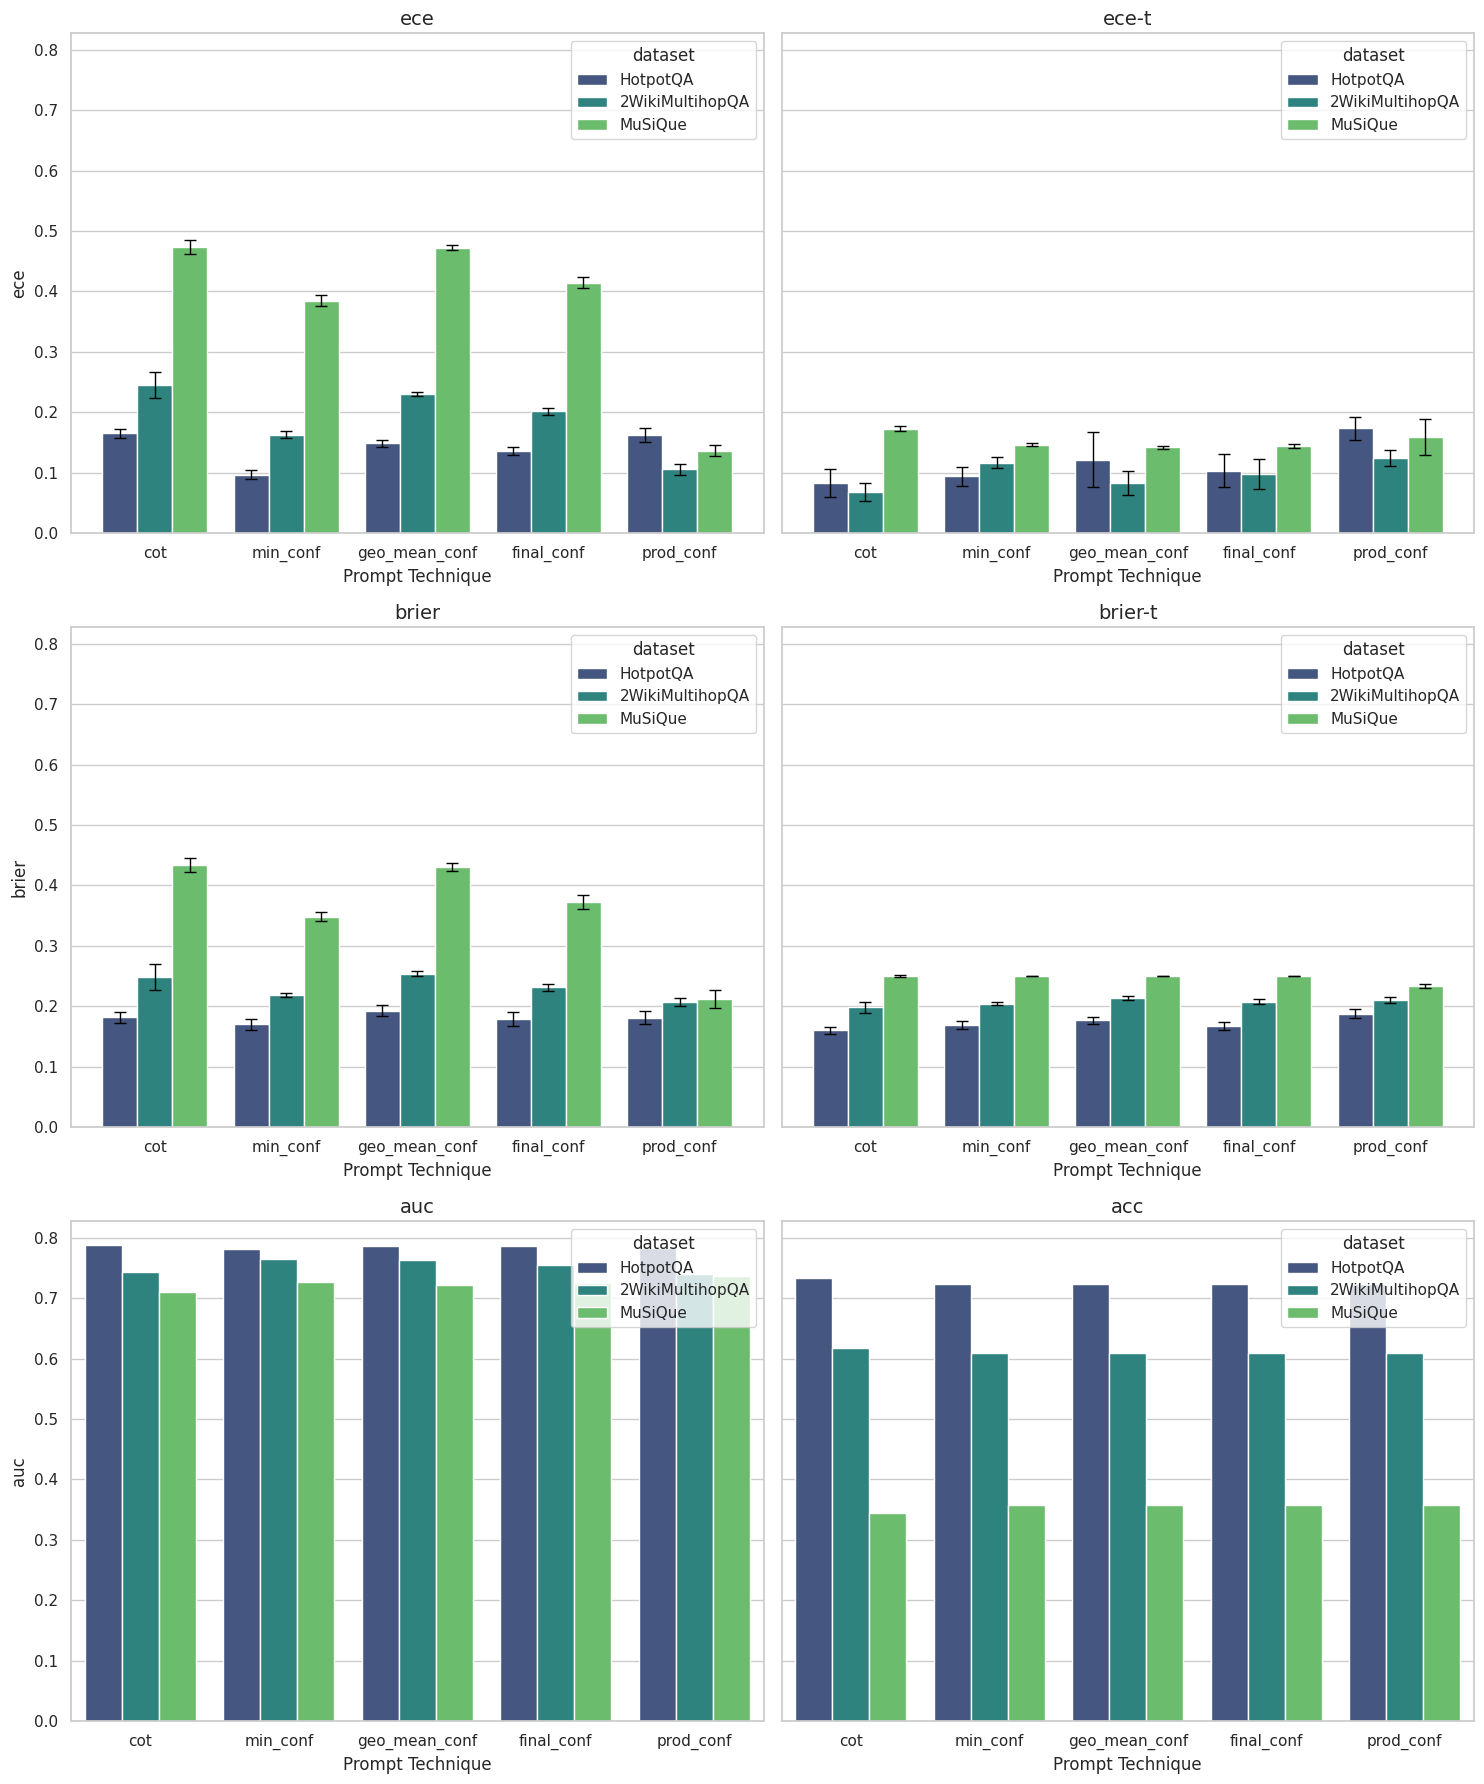

In [34]:
plot_metrics(selected_metrics)

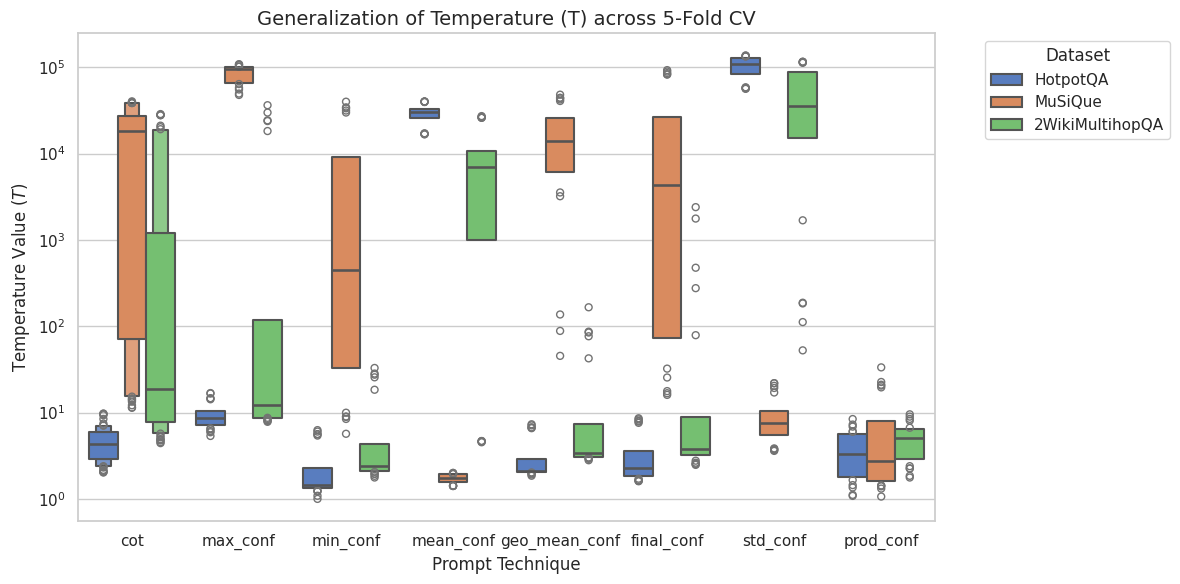

In [32]:
def plot_t_distribution(df):
    plt.figure(figsize=(12, 6))
    sns.set_theme(style="whitegrid")
    
    # Violin plot shows the full distribution of T across the 10 folds
    sns.boxenplot(
        data=df, 
        x="conf_type", 
        y="T", 
        hue="dataset", 
        #inner="quart",      # Shows the median and quartiles inside the violin
        linewidth=1.5,
        palette="muted",
        log_scale=True,
    )
    
    # Add a horizontal line at T=1.0 (The "Perfectly Calibrated" line)
    #plt.axhline(1.0, color='red', linestyle='--', alpha=0.6, label="Perfectly Calibrated (T=1)")
    
    plt.title(f"Generalization of Temperature (T) across {NUM_SPLITS}-Fold CV", fontsize=14)
    plt.ylabel("Temperature Value ($T$)", fontsize=12)
    plt.xlabel("Prompt Technique", fontsize=12)
    plt.legend(title="Dataset", bbox_to_anchor=(1.05, 1), loc='upper left')
    
    plt.tight_layout()
    plt.show()

df_plot = metrics_df.explode("T")
plot_t_distribution(df_plot)